# Simulation Size Analysis

This notebook chooses a simulation size for the dynamic programming model.

The design is:

1. Load the empirical moment files for `udd1`, `udd2`, and `udd3`.
2. Keep the empirical moments that are probabilities or shares.
3. Compute approximate empirical standard errors for those moments.
4. Load the optimized structural parameters for each education group.
5. For each education group, solve the model once using that group's parameter vector.
6. For each simulation size, run the simulation several times using different random seeds.
7. Use the standard deviation of each simulated moment across seeds as the measure of simulation uncertainty.
8. Compare simulation uncertainty to the empirical sampling uncertainty of the corresponding data moment.

The main object is:

$$
\frac{SD_{seed}(m^{sim}_{N,k,a,e})}{SE(m^{data}_{k,a,e})}
$$

where:

- \(N\) is the number of simulated individuals,
- \(k\) is the moment,
- \(a\) is age,
- \(e\) is education group,
- \(SD_{seed}(m^{sim}_{N,k,a,e})\) is the standard deviation of the simulated moment across random seeds,
- \(SE(m^{data}_{k,a,e})\) is the approximate empirical standard error.

This avoids choosing an arbitrary high-\(N\) benchmark. The simulation size is instead selected by asking whether simulation-induced variation is small relative to empirical sampling uncertainty.

## 1. Setup

Run this cell first. It sets the project path, imports packages, and enables 64-bit precision in JAX.

In [2]:

%reload_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import importlib
import time

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Change this depending on notebook location:
# 0 = notebook is in the project root
# 1 = notebook is one folder below the project root
# 2 = notebook is two folders below the project root
amount_of_levels = 0

DIR = Path.cwd().resolve().parents[amount_of_levels]

if str(DIR) not in sys.path:
    sys.path.insert(0, str(DIR))

import project_paths as pp
from project_imports import *

importlib.reload(pp)

print("Project root:", pp.DIR)
print("JAX x64 enabled:", jax.config.read("jax_enable_x64"))

Project root: C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper
JAX x64 enabled: True


## 2. Files and moment selection

The empirical data are available only as published moments. Therefore, empirical standard errors can only be approximated cleanly for moments that are probabilities or shares.

The continuous moments are still useful for model evaluation, but they are excluded from this specific standard-error comparison because their empirical standard errors require either raw microdata or additional variance information.

In [3]:

EDUCATION_LEVELS = ["udd1", "udd2", "udd3"]

EMPIRICAL_MOMENT_FILES = {
    "udd1": pp.MOMENTS_DIR / "moments_udd1.txt",
    "udd2": pp.MOMENTS_DIR / "moments_udd2.txt",
    "udd3": pp.MOMENTS_DIR / "moments_udd3.txt",
}

OPTIMIZED_PARAM_FILES = {
    "udd1": pp.STRUCTURAL_RESULTS_DIR / "optimized_params_udd1.txt",
    "udd2": pp.STRUCTURAL_RESULTS_DIR / "optimized_params_udd2.txt",
    "udd3": pp.STRUCTURAL_RESULTS_DIR / "optimized_params_udd3.txt",
}

# Moments that are probabilities/shares and therefore have approximate binomial standard errors.
SHARE_MOMENTS = [
    "prob_work",
    "hours_0",
    "hours_1",
    "hours_2",
    "hours_3",
    "hours_4",
    "work_work",
    "nowork_nowork",
]

# Continuous and higher-order moments deliberately excluded from this specific comparison.
EXCLUDED_FROM_SE_COMPARISON = [
    "avg_wealth",
    "avg_experience",
    "avg_labor_income",
    "avg_wage",
    "avg_hours",
    "var_wage",
    "skew_wage",
    "pens",
]

print("Education levels:", EDUCATION_LEVELS)
print("Share/probability moments used in SE comparison:")
print(SHARE_MOMENTS)
print("\nContinuous/higher-order moments excluded from SE comparison:")
print(EXCLUDED_FROM_SE_COMPARISON)

Education levels: ['udd1', 'udd2', 'udd3']
Share/probability moments used in SE comparison:
['prob_work', 'hours_0', 'hours_1', 'hours_2', 'hours_3', 'hours_4', 'work_work', 'nowork_nowork']

Continuous/higher-order moments excluded from SE comparison:
['avg_wealth', 'avg_experience', 'avg_labor_income', 'avg_wage', 'avg_hours', 'var_wage', 'skew_wage', 'pens']


## 3. Load empirical moments and compute empirical standard errors

For each share/probability moment, the empirical standard error is approximated by:

$$
SE(\hat p) = \sqrt{\frac{\hat p(1-\hat p)}{n}}
$$

where \(n\) is the reported age-cell frequency `_FREQ_`.

For `work_work` and `nowork_nowork`, `_FREQ_` is used as an approximation to the denominator. If the original transition denominators are available elsewhere, they should replace `_FREQ_` for those two moments.

In [4]:

def load_empirical_moments(path, education_label):
    """Load one empirical moment file and standardize the age column name."""
    df = pd.read_csv(path)

    if "ALDER" in df.columns:
        df = df.rename(columns={"ALDER": "age"})

    required = ["age", "_FREQ_"]
    missing_required = [col for col in required if col not in df.columns]
    if missing_required:
        raise KeyError(f"{path} is missing required columns: {missing_required}")

    df.insert(0, "education", education_label)

    # Convert all non-label columns to numeric where possible.
    for col in df.columns:
        if col != "education":
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


empirical_moments_wide = pd.concat(
    [
        load_empirical_moments(path, education_label)
        for education_label, path in EMPIRICAL_MOMENT_FILES.items()
    ],
    ignore_index=True,
)

# Keep a share-only wide version for clarity.
empirical_share_columns = ["education", "age", "_FREQ_"] + [
    col for col in SHARE_MOMENTS if col in empirical_moments_wide.columns
]
empirical_share_moments_wide = empirical_moments_wide[empirical_share_columns].copy()

# Check that selected probability/share moments are inside [0, 1] when non-missing.
range_check = empirical_share_moments_wide.melt(
    id_vars=["education", "age", "_FREQ_"],
    value_vars=[col for col in SHARE_MOMENTS if col in empirical_share_moments_wide.columns],
    var_name="moment",
    value_name="data_value",
)

outside_unit_interval = range_check.loc[
    range_check["data_value"].notna()
    & ((range_check["data_value"] < 0) | (range_check["data_value"] > 1))
]

if outside_unit_interval.empty:
    print("All selected empirical share/probability moments are within [0, 1].")
else:
    print("Warning: some selected moments are outside [0, 1]. Inspect these rows:")
    display(outside_unit_interval)

print("\nEmpirical share-moment columns kept:")
print(empirical_share_moments_wide.columns.tolist())

display(empirical_share_moments_wide.head())

All selected empirical share/probability moments are within [0, 1].

Empirical share-moment columns kept:
['education', 'age', '_FREQ_', 'prob_work', 'hours_0', 'hours_1', 'hours_2', 'hours_3', 'hours_4', 'work_work', 'nowork_nowork']


,education,age,_FREQ_,prob_work,hours_0,hours_1,hours_2,hours_3,hours_4,work_work,nowork_nowork
0,udd1,30,2840,0.740845,0.259155,0.118310,0.108099,0.108451,0.405986,NaN,NaN
1,udd1,31,5097,0.725525,0.274475,0.107122,0.098097,0.101236,0.419070,0.672383,0.237816
2,udd1,32,7282,0.728371,0.271629,0.103818,0.096127,0.099423,0.429003,0.660332,0.238393
3,udd1,33,9171,0.729473,0.270527,0.106531,0.085814,0.103696,0.433431,0.669245,0.236301
4,udd1,34,11180,0.722898,0.277102,0.098927,0.081216,0.099463,0.443292,0.666112,0.239242


In [5]:

def compute_empirical_sampling_error(empirical_share_wide, share_moments=SHARE_MOMENTS):
    """Convert empirical share moments to long format and compute approximate binomial SEs."""
    value_vars = [col for col in share_moments if col in empirical_share_wide.columns]

    empirical_long = empirical_share_wide.melt(
        id_vars=["education", "age", "_FREQ_"],
        value_vars=value_vars,
        var_name="moment",
        value_name="data_value",
    )

    empirical_long = empirical_long.rename(columns={"_FREQ_": "n_data"})

    p = empirical_long["data_value"].clip(lower=0, upper=1)
    n = empirical_long["n_data"]

    empirical_long["data_se"] = np.sqrt((p * (1 - p)) / n)

    invalid = (
        empirical_long["data_value"].isna()
        | empirical_long["n_data"].isna()
        | (empirical_long["n_data"] <= 0)
    )
    empirical_long.loc[invalid, "data_se"] = np.nan

    empirical_long["denominator_note"] = np.where(
        empirical_long["moment"].isin(["work_work", "nowork_nowork"]),
        "Approximate: uses total age-cell frequency",
        "Uses total age-cell frequency",
    )

    return empirical_long


empirical_sampling_error_long = compute_empirical_sampling_error(empirical_share_moments_wide)

display(empirical_sampling_error_long.head(12))

,education,age,n_data,moment,data_value,data_se,denominator_note
0,udd1,30,2840,prob_work,0.740845,0.008222,Uses total age-cell frequency
1,udd1,31,5097,prob_work,0.725525,0.006251,Uses total age-cell frequency
2,udd1,32,7282,prob_work,0.728371,0.005212,Uses total age-cell frequency
3,udd1,33,9171,prob_work,0.729473,0.004639,Uses total age-cell frequency
4,udd1,34,11180,prob_work,0.722898,0.004233,Uses total age-cell frequency
5,udd1,35,13112,prob_work,0.718883,0.003926,Uses total age-cell frequency
6,udd1,36,17702,prob_work,0.747882,0.003264,Uses total age-cell frequency
7,udd1,37,22115,prob_work,0.763328,0.002858,Uses total age-cell frequency
8,udd1,38,26699,prob_work,0.777520,0.002545,Uses total age-cell frequency
9,udd1,39,31731,prob_work,0.786896,0.002299,Uses total age-cell frequency


## 4. Load optimized structural parameters for each education group

Each education group has its own optimized parameter file. The model must therefore be solved separately for `udd1`, `udd2`, and `udd3`.

The parameter files use names such as `sigma` and `beta`. These are mapped into the names used by the model code, such as `income_shock_std` and `discount_factor`.

In [6]:

def parse_value_from_txt(value):
    """Parse scalar values and bracketed vectors from the optimized parameter files."""
    value = str(value).strip()

    if value.startswith("[") and value.endswith("]"):
        return np.fromstring(value.strip("[]"), sep=" ")

    return float(value)


def load_optimized_params(path):
    """Load an optimized parameter file with one parameter-value pair per line."""
    raw = {}

    with open(path, "r") as file:
        for line in file:
            line = line.strip()

            if not line:
                continue

            # Skip header lines such as "value".
            if line.lower() == "value":
                continue

            parts = line.split(maxsplit=1)
            if len(parts) != 2:
                continue

            name, value = parts
            raw[name] = parse_value_from_txt(value)

    return raw


def normalize_structural_params(raw_params):
    """Map optimized parameter names to the parameter names used by the model code."""
    params = {}

    params["interest_rate"] = float(raw_params["interest_rate"])
    params["income_shock_mean"] = float(raw_params.get("income_shock_mean", 0.0))
    params["income_shock_std"] = float(raw_params.get("income_shock_std", raw_params.get("sigma")))
    params["taste_shock_scale"] = float(raw_params["taste_shock_scale"])
    params["discount_factor"] = float(raw_params.get("discount_factor", raw_params.get("beta")))
    params["rho"] = float(raw_params["rho"])
    params["gamma"] = jnp.asarray(raw_params["gamma"], dtype=jnp.float64)

    params["beta0"] = float(raw_params["beta0"])
    params["beta1"] = float(raw_params["beta1"])
    params["beta2"] = float(raw_params["beta2"])

    params["kappa1"] = float(raw_params["kappa1"])
    params["kappa2"] = float(raw_params["kappa2"])
    params["phi"] = float(raw_params["phi"])
    params["b_scale"] = float(raw_params["b_scale"])
    params["xi"] = float(raw_params["xi"])
    params["eta_edu"] = float(raw_params["eta_edu"])

    # These are also in model_specs, but keeping them in params preserves the existing model interface.
    params["alpha1"] = float(raw_params.get("alpha1", alpha1))
    params["alpha2"] = float(raw_params.get("alpha2", alpha2))

    return params

## 5. Fixed solver specification

This notebook is only about simulation size. The numerical grid is therefore fixed throughout the exercise. Solver-grid sensitivity belongs in the separate model-specification notebook.

In [7]:

# Fixed model specification used in this simulation-size exercise.
BASELINE_N_ASSETS = 20
BASELINE_N_EXPERIENCE = 5
BASELINE_N_QUAD_POINTS = 5

n_periods = 55
labour_choices = np.arange(5, dtype=np.int32)
alpha1, alpha2 = np.loadtxt(pp.STRUCTURAL_RESULTS_DIR / "mortality_params.txt")

model_specs = {
    "n_periods": n_periods,
    "labour_choices": labour_choices,
    "hours": jnp.array([0, 250, 750, 1300, 1900], dtype=jnp.float64),
    "max_hours": 1500,
    "start_age": 30,
    "tax_threshold1": 0.480,
    "tax_threshold2": 5.698,
    "tax_base_rate": 0.38,
    "tax_top_rate": 0.5,
    "retirement_age": 67,
    "oap_base_amount": 0.80328,
    "oap_max_supplement": 0.92940,
    "supp_threshold": 0.79300,
    "oap_threshold": 3.3592,
    "supp_reduction_rate": 0.309,
    "oap_reduction_rate": 0.3,
    "alpha1": jnp.asarray(alpha1, dtype=jnp.float64),
    "alpha2": jnp.asarray(alpha2, dtype=jnp.float64),
    "max_init_experience": 5,
    "max_ret_period": 45,  # Age 75.
    "min_ret_period": 30,  # Age 60.
}

stochastic_states_transitions = {
    "survival": prob_survival,
}

hours_map = {
    i: int(h)
    for i, h in enumerate(np.asarray(model_specs["hours"]))
}

print("Fixed grid:")
print(f"n_assets      = {BASELINE_N_ASSETS}")
print(f"n_experience  = {BASELINE_N_EXPERIENCE}")
print(f"n_quad_points = {BASELINE_N_QUAD_POINTS}")

Fixed grid:
n_assets      = 20
n_experience  = 5
n_quad_points = 5


## 6. Helper functions for solving and simulating

The model is solved once per education group. For a given education group, all simulation sizes and random seeds reuse the same solved policy functions.

Initial states are constructed from the corresponding education group's age-30 empirical moments:

- `hours_0` to `hours_4` determine the initial lagged labor choice distribution,
- `avg_wealth` determines initial assets when available,
- `avg_experience` determines initial experience when available; otherwise the notebook falls back to `1.0`.

In [8]:

def make_model_config(
    n_assets=BASELINE_N_ASSETS,
    n_experience=BASELINE_N_EXPERIENCE,
    n_quad_points=BASELINE_N_QUAD_POINTS,
):
    """Create the numerical model configuration."""
    return {
        "n_periods": n_periods,
        "choices": labour_choices,
        "n_quad_points": n_quad_points,
        "continuous_states": {
            "assets_end_of_period": jnp.linspace(0.0, 50.0, n_assets, dtype=jnp.float64),
            "experience": jnp.linspace(0.0, 1.0, n_experience, dtype=jnp.float64),
        },
        "stochastic_states": {
            "survival": [0, 1],
        },
    }


def get_initial_moment_row(education, start_age=None):
    """Return the empirical moment row used for the initial simulation state."""
    if start_age is None:
        start_age = model_specs["start_age"]

    rows = empirical_moments_wide.loc[
        (empirical_moments_wide["education"] == education)
        & (empirical_moments_wide["age"] == start_age)
    ]

    if rows.empty:
        raise ValueError(f"No empirical moment row found for {education} at age {start_age}.")

    return rows.iloc[0]


def get_initial_choice_probabilities(education):
    """Use age-30 empirical hours-bin shares as the initial lagged-choice distribution."""
    row = get_initial_moment_row(education)
    probs = row[["hours_0", "hours_1", "hours_2", "hours_3", "hours_4"]].to_numpy(dtype=float)

    if np.any(~np.isfinite(probs)) or probs.sum() <= 0:
        raise ValueError(f"Invalid initial hours probabilities for {education}: {probs}")

    # Normalize defensively in case of small rounding errors.
    probs = probs / probs.sum()
    return probs


def get_initial_assets_and_experience(education):
    """Use education-specific empirical initial assets and experience when available."""
    row = get_initial_moment_row(education)

    initial_assets = row.get("avg_wealth", np.nan)
    if not np.isfinite(initial_assets):
        initial_assets = 0.0

    initial_experience = row.get("avg_experience", np.nan)
    if not np.isfinite(initial_experience):
        initial_experience = 1.0

    return float(initial_assets), float(initial_experience)


def make_initial_states(n_individuals, education, seed=132):
    """Create education-specific initial states for the simulated individuals."""
    key = jax.random.PRNGKey(seed)

    labels = jnp.array([0, 1, 2, 3, 4], dtype=jnp.int32)
    probs = jnp.asarray(get_initial_choice_probabilities(education), dtype=jnp.float64)
    initial_assets, initial_experience = get_initial_assets_and_experience(education)

    lagged_choice = jax.random.choice(
        key,
        a=labels,
        shape=(n_individuals,),
        p=probs,
        replace=True,
    )

    return {
        "period": jnp.zeros(n_individuals, dtype=jnp.int32),
        "lagged_choice": lagged_choice,
        "experience": jnp.full(n_individuals, initial_experience, dtype=jnp.float64),
        "survival": jnp.ones(n_individuals, dtype=jnp.int32),
        "assets_begin_of_period": jnp.full(n_individuals, initial_assets, dtype=jnp.float64),
    }


def solve_model_once(params, n_assets=BASELINE_N_ASSETS, n_experience=BASELINE_N_EXPERIENCE, n_quad_points=BASELINE_N_QUAD_POINTS):
    """Set up, validate, and solve the model one time for one parameter vector."""
    model_config = make_model_config(
        n_assets=n_assets,
        n_experience=n_experience,
        n_quad_points=n_quad_points,
    )

    model = dcegm.setup_model(
        model_config=model_config,
        model_specs=model_specs,
        utility_functions=utility_functions,
        utility_functions_final_period=final_period_utility,
        budget_constraint=budget_dcegm_initial,
        state_space_functions=create_state_space_function_dict(),
        stochastic_states_transitions=stochastic_states_transitions,
    )

    model.validate_exogenous(params)

    t0 = time.time()
    model_solved = model.solve(params)
    solve_time = time.time() - t0

    return model, model_solved, solve_time


def simulate_from_solved_model(model_solved, education, n_individuals, seed=132, store_sim=False):
    """Simulate from a fixed solved model and compute simulated moments."""
    states_initial = make_initial_states(n_individuals=n_individuals, education=education, seed=seed)

    t0 = time.time()
    sim = model_solved.simulate(states_initial=states_initial, seed=seed)
    sim_time = time.time() - t0

    moments = compute_simulation_moments_with_ci(
        sim,
        start_age=model_specs["start_age"],
        hours_map=hours_map,
    )

    out = {
        "education": education,
        "label": f"{education}, N={n_individuals}, seed={seed}",
        "n_individuals": n_individuals,
        "seed": seed,
        "n_assets": BASELINE_N_ASSETS,
        "n_experience": BASELINE_N_EXPERIENCE,
        "n_quad_points": BASELINE_N_QUAD_POINTS,
        "sim_time": sim_time,
        "moments": moments,
    }

    if store_sim:
        out["sim"] = sim

    return out

## 7. Inspect education-specific initial conditions and parameter files

This cell is a sanity check. It confirms that each education group has its own initial moments and its own parameter file.

In [9]:

initial_condition_rows = []
parameter_preview_rows = []

for education in EDUCATION_LEVELS:
    initial_probs = get_initial_choice_probabilities(education)
    initial_assets, initial_experience = get_initial_assets_and_experience(education)

    initial_condition_rows.append({
        "education": education,
        "initial_assets": initial_assets,
        "initial_experience": initial_experience,
        "p_hours_0": initial_probs[0],
        "p_hours_1": initial_probs[1],
        "p_hours_2": initial_probs[2],
        "p_hours_3": initial_probs[3],
        "p_hours_4": initial_probs[4],
        "prob_sum": initial_probs.sum(),
    })

    raw_params = load_optimized_params(OPTIMIZED_PARAM_FILES[education])
    params = normalize_structural_params(raw_params)
    parameter_preview_rows.append({
        "education": education,
        "discount_factor": params["discount_factor"],
        "income_shock_std": params["income_shock_std"],
        "taste_shock_scale": params["taste_shock_scale"],
        "rho": params["rho"],
        "eta_edu": params["eta_edu"],
        "beta0": params["beta0"],
        "beta1": params["beta1"],
        "beta2": params["beta2"],
    })

initial_conditions = pd.DataFrame(initial_condition_rows)
parameter_preview = pd.DataFrame(parameter_preview_rows)

display(initial_conditions)
display(parameter_preview)

,education,initial_assets,initial_experience,p_hours_0,p_hours_1,p_hours_2,p_hours_3,p_hours_4,prob_sum
0,udd1,0.505047,1.0,0.259155,0.118310,0.108099,0.108451,0.405986,1.0
1,udd2,0.832253,1.0,0.163522,0.154537,0.137466,0.113208,0.431267,1.0
2,udd3,1.567615,1.0,0.154497,0.103766,0.096080,0.102998,0.542659,1.0


,education,discount_factor,income_shock_std,taste_shock_scale,rho,eta_edu,beta0,beta1,beta2
0,udd1,0.964564,0.147421,1.001116,0.445423,0.43848,-6.896104,0.027168,-0.000177
1,udd2,0.983347,0.336435,1.538931,0.454979,0.69164,-7.345297,0.052208,-0.000400
2,udd3,0.986276,0.200000,2.400000,0.454603,1.10158,-7.721101,0.074183,-0.000589


## 8. Run the simulation-size experiment

For each education group, this cell:

1. loads that group's optimized parameters,
2. solves the model once,
3. simulates each candidate sample size for several random seeds,
4. stores the simulated moments.

The variable `SIMULATION_SEEDS` controls how precisely the simulation standard deviation is estimated. Increase the number of seeds if runtime allows.

In [10]:

SIMULATION_SIZES = [10_000, 25_000, 50_000, 100_000, 250_000, 500_000]

# More seeds = better estimate of simulation uncertainty.
# 5 is acceptable for a term paper; 10 is stronger if runtime is acceptable.
SIMULATION_SEEDS = [101, 202, 303, 404, 505, 606, 707, 808, 909, 1010]

simulation_results = []
solver_summary_rows = []

for education in EDUCATION_LEVELS:
    print(f"\n=== {education}: loading parameters and solving model ===")

    raw_params = load_optimized_params(OPTIMIZED_PARAM_FILES[education])
    params = normalize_structural_params(raw_params)

    model, model_solved, solve_time = solve_model_once(params=params)

    solver_summary_rows.append({
        "education": education,
        "n_assets": BASELINE_N_ASSETS,
        "n_experience": BASELINE_N_EXPERIENCE,
        "n_quad_points": BASELINE_N_QUAD_POINTS,
        "solve_time_seconds": solve_time,
    })

    print(f"Solved {education} model in {solve_time:.3f} seconds.")

    for n_sim in SIMULATION_SIZES:
        for seed in SIMULATION_SEEDS:
            result = simulate_from_solved_model(
                model_solved=model_solved,
                education=education,
                n_individuals=n_sim,
                seed=seed,
                store_sim=False,
            )

            result["solve_time"] = solve_time
            simulation_results.append(result)

            print(
                f"{education}, N={n_sim}, seed={seed}: "
                f"solve_time={solve_time:.3f}s, "
                f"sim_time={result['sim_time']:.3f}s"
            )

solver_summary = pd.DataFrame(solver_summary_rows)

display(solver_summary)


=== udd1: loading parameters and solving model ===
State specific choice set not provided. Assume all choices are available in every state.
Update function for state space not given. Assume states only change with an increase of the period and lagged choice.
Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  25
Model setup complete.

Solved udd1 model in 2.595 seconds.
udd1, N=10000, seed=101: solve_time=2.595s, sim_time=3.079s
udd1, N=10000, seed=202: solve_time=2.595s, sim_time=1.443s
udd1, N=10000, seed=303: solve_time=2.595s, sim_time=1.511s
udd1, N=10000, seed=404: solve_time=2.595s, sim_time=1.558s
udd1, N=10000, seed=505: solve_time=2.595s, sim_time=1.554s
udd1, N=10000, seed=606: solve_time=2.595s, sim_time=1.812s
udd1, N=10000, seed=707: solve_time=2.595s, sim_time=1.537s
udd1, 

,education,n_assets,n_experience,n_quad_points,solve_time_seconds
0,udd1,20,5,5,2.595287
1,udd2,20,5,5,2.383970
2,udd3,20,5,5,2.494687


## 9. Convert simulated moments to a wide dataset

This creates a simulated moment dataset that looks like the empirical `moments_wide` files, except that it also contains simulation metadata such as education group, sample size, seed, and runtime.

In [11]:

def moments_to_dataframe(moments):
    """Convert a simulated moment object to a pandas DataFrame."""
    if isinstance(moments, pd.DataFrame):
        return moments.copy()
    if isinstance(moments, dict):
        return pd.DataFrame(moments)
    return pd.DataFrame(moments)


def simulated_moments_to_wide(result):
    """Convert one simulation result to a wide moment table with metadata."""
    df = moments_to_dataframe(result["moments"])

    if "ALDER" in df.columns and "age" not in df.columns:
        df = df.rename(columns={"ALDER": "age"})

    if "age" not in df.columns:
        if "period" in df.columns:
            df = df.copy()
            df["age"] = df["period"] + model_specs["start_age"]
        else:
            raise KeyError("Simulated moments must contain either an 'age' or 'period' column.")

    # Insert metadata first so the simulated wide dataset is easy to inspect and merge.
    df = df.copy()
    df.insert(0, "education", result["education"])
    df.insert(1, "n_individuals", result["n_individuals"])
    df.insert(2, "seed", result["seed"])
    df.insert(3, "sim_time_seconds", result["sim_time"])
    df.insert(4, "solve_time_seconds", result["solve_time"])
    df.insert(5, "n_assets", result["n_assets"])
    df.insert(6, "n_experience", result["n_experience"])
    df.insert(7, "n_quad_points", result["n_quad_points"])

    # Put age immediately after metadata if possible.
    metadata_cols = [
        "education", "n_individuals", "seed", "sim_time_seconds", "solve_time_seconds",
        "n_assets", "n_experience", "n_quad_points", "age"
    ]
    remaining_cols = [col for col in df.columns if col not in metadata_cols]
    return df[metadata_cols + remaining_cols]


simulated_moments_wide = pd.concat(
    [simulated_moments_to_wide(result) for result in simulation_results],
    ignore_index=True,
)

display(simulated_moments_wide.head())
print("Simulated moments wide shape:", simulated_moments_wide.shape)

,education,n_individuals,seed,sim_time_seconds,solve_time_seconds,n_assets,n_experience,n_quad_points,age,N,...,avg_hours_upper,avg_consumption_se,avg_consumption_lower,avg_consumption_upper,avg_experience_se,avg_experience_lower,avg_experience_upper,avg_labor_income_se,avg_labor_income_lower,avg_labor_income_upper
0,udd1,10000,101,3.078828,2.595287,20,5,5,30,10000,...,1523.409928,0.000000,0.505047,0.505047,NaN,NaN,NaN,NaN,NaN,NaN
1,udd1,10000,101,3.078828,2.595287,20,5,5,31,10000,...,1565.632683,0.006088,1.209325,1.233189,0.000949,5.946310,5.950031,0.017579,2.037737,2.106647
2,udd1,10000,101,3.078828,2.595287,20,5,5,32,10000,...,1582.372495,0.006277,1.386811,1.411416,0.002760,6.825265,6.836086,0.017918,2.160616,2.230853
3,udd1,10000,101,3.078828,2.595287,20,5,5,33,9999,...,1584.389718,0.006424,1.506124,1.531308,0.004835,7.677832,7.696785,0.018134,2.328625,2.399711
4,udd1,10000,101,3.078828,2.595287,20,5,5,34,9997,...,1603.078536,0.006563,1.607838,1.633564,0.006931,8.513173,8.540344,0.018270,2.389573,2.461191


Simulated moments wide shape: (9900, 66)


## 10. Compute simulation uncertainty by age and moment

For each education group, sample size, age, and moment, the notebook computes:

$$
SD_{seed}(m^{sim}_{N,k,a,e})
$$

This is the simulation uncertainty caused by the random simulation seed at a fixed sample size.

In [12]:

def simulated_share_moments_to_long(simulated_wide, share_moments=SHARE_MOMENTS):
    """Extract simulated share/probability moments in long format."""
    available_moments = [col for col in share_moments if col in simulated_wide.columns]
    missing_moments = [col for col in share_moments if col not in simulated_wide.columns]

    if missing_moments:
        print(f"Warning: simulated output is missing share moments: {missing_moments}")

    id_vars = [
        "education",
        "n_individuals",
        "seed",
        "age",
        "sim_time_seconds",
        "solve_time_seconds",
        "n_assets",
        "n_experience",
        "n_quad_points",
    ]

    long = simulated_wide.melt(
        id_vars=id_vars,
        value_vars=available_moments,
        var_name="moment",
        value_name="sim_value",
    )

    long["sim_value"] = pd.to_numeric(long["sim_value"], errors="coerce")

    return long


simulated_share_moments_long = simulated_share_moments_to_long(simulated_moments_wide)

simulation_uncertainty = (
    simulated_share_moments_long
    .groupby(["education", "n_individuals", "age", "moment"], as_index=False)
    .agg(
        mean_sim_value=("sim_value", "mean"),
        simulation_sd=("sim_value", "std"),
        min_sim_value=("sim_value", "min"),
        max_sim_value=("sim_value", "max"),
        n_seeds=("seed", "nunique"),
        mean_sim_time_seconds=("sim_time_seconds", "mean"),
        solve_time_seconds=("solve_time_seconds", "first"),
        n_assets=("n_assets", "first"),
        n_experience=("n_experience", "first"),
        n_quad_points=("n_quad_points", "first"),
    )
)

# With only one seed, the standard deviation is undefined. This should not happen if SIMULATION_SEEDS has length > 1.
simulation_uncertainty.loc[simulation_uncertainty["n_seeds"] <= 1, "simulation_sd"] = np.nan

display(simulation_uncertainty.head(12))

,education,n_individuals,age,moment,mean_sim_value,simulation_sd,min_sim_value,max_sim_value,n_seeds,mean_sim_time_seconds,solve_time_seconds,n_assets,n_experience,n_quad_points
0,udd1,10000,30,hours_0,0.31728,0.003172,0.3125,0.3244,10,1.704289,2.595287,20,5,5
1,udd1,10000,30,hours_1,0.07703,0.001984,0.0732,0.0800,10,1.704289,2.595287,20,5,5
2,udd1,10000,30,hours_2,0.07129,0.002186,0.0669,0.0744,10,1.704289,2.595287,20,5,5
3,udd1,10000,30,hours_3,0.09103,0.002804,0.0860,0.0955,10,1.704289,2.595287,20,5,5
4,udd1,10000,30,hours_4,0.44337,0.003606,0.4382,0.4484,10,1.704289,2.595287,20,5,5
5,udd1,10000,30,nowork_nowork,0.15095,0.003681,0.1471,0.1577,10,1.704289,2.595287,20,5,5
6,udd1,10000,30,prob_work,0.68272,0.003172,0.6756,0.6875,10,1.704289,2.595287,20,5,5
7,udd1,10000,30,work_work,0.57382,0.004468,0.5653,0.5798,10,1.704289,2.595287,20,5,5
8,udd1,10000,31,hours_0,0.30075,0.003823,0.2929,0.3069,10,1.704289,2.595287,20,5,5
9,udd1,10000,31,hours_1,0.06705,0.001999,0.0632,0.0697,10,1.704289,2.595287,20,5,5


## 11. Compare simulation uncertainty to empirical sampling uncertainty

The key ratio is:

$$
\frac{SD_{seed}(m^{sim}_{N,k,a,e})}{SE(m^{data}_{k,a,e})}
$$

Interpretation:

- ratio below `1.00`: simulation uncertainty is smaller than one empirical standard error,
- ratio below `0.50`: simulation uncertainty is less than half an empirical standard error,
- ratio below `0.25`: simulation uncertainty is small relative to empirical sampling uncertainty.

In [13]:

simulation_vs_sampling_error = simulation_uncertainty.merge(
    empirical_sampling_error_long,
    on=["education", "age", "moment"],
    how="inner",
)

simulation_vs_sampling_error["simulation_sd_to_data_se"] = (
    simulation_vs_sampling_error["simulation_sd"] / simulation_vs_sampling_error["data_se"]
)

# Avoid infinite ratios caused by zero or missing empirical standard errors.
simulation_vs_sampling_error = simulation_vs_sampling_error.replace([np.inf, -np.inf], np.nan)

comparison_columns = [
    "education",
    "n_individuals",
    "age",
    "moment",
    "mean_sim_value",
    "simulation_sd",
    "data_value",
    "n_data",
    "data_se",
    "simulation_sd_to_data_se",
    "n_seeds",
]

display(simulation_vs_sampling_error[comparison_columns].head(12))

,education,n_individuals,age,moment,mean_sim_value,simulation_sd,data_value,n_data,data_se,simulation_sd_to_data_se,n_seeds
0,udd1,10000,30,hours_0,0.31728,0.003172,0.259155,2840,0.008222,0.385749,10
1,udd1,10000,30,hours_1,0.07703,0.001984,0.118310,2840,0.006061,0.327341,10
2,udd1,10000,30,hours_2,0.07129,0.002186,0.108099,2840,0.005827,0.375101,10
3,udd1,10000,30,hours_3,0.09103,0.002804,0.108451,2840,0.005835,0.480490,10
4,udd1,10000,30,hours_4,0.44337,0.003606,0.405986,2840,0.009215,0.391339,10
5,udd1,10000,30,nowork_nowork,0.15095,0.003681,NaN,2840,NaN,NaN,10
6,udd1,10000,30,prob_work,0.68272,0.003172,0.740845,2840,0.008222,0.385749,10
7,udd1,10000,30,work_work,0.57382,0.004468,NaN,2840,NaN,NaN,10
8,udd1,10000,31,hours_0,0.30075,0.003823,0.274475,5097,0.006251,0.611593,10
9,udd1,10000,31,hours_1,0.06705,0.001999,0.107122,5097,0.004332,0.461467,10


### Summary

In [ ]:
def percentile_90(x):
    valid = x.dropna()
    if len(valid) == 0:
        return np.nan
    return np.nanquantile(valid, 0.90)


def share_below(threshold):
    def _share(x):
        valid = x.dropna()
        if len(valid) == 0:
            return np.nan
        return np.mean(valid < threshold)
    _share.__name__ = f"share_below_{threshold}"
    return _share


simulation_size_summary_by_education = (
    simulation_vs_sampling_error
    .groupby(["education", "n_individuals"], as_index=False)
    .agg(
        n_compared_cells=("simulation_sd_to_data_se", "count"),
        mean_sd_to_se=("simulation_sd_to_data_se", "mean"),
        median_sd_to_se=("simulation_sd_to_data_se", "median"),
        p90_sd_to_se=("simulation_sd_to_data_se", percentile_90),
        max_sd_to_se=("simulation_sd_to_data_se", "max"),
        share_below_0_25_se=("simulation_sd_to_data_se", share_below(0.25)),
        share_below_0_50_se=("simulation_sd_to_data_se", share_below(0.50)),
        share_below_1_00_se=("simulation_sd_to_data_se", share_below(1.00)),
        mean_simulation_sd=("simulation_sd", "mean"),
        max_simulation_sd=("simulation_sd", "max"),
        mean_sim_time_seconds=("mean_sim_time_seconds", "mean"),
        solve_time_seconds=("solve_time_seconds", "first"),
        n_seeds=("n_seeds", "first"),
        n_assets=("n_assets", "first"),
        n_experience=("n_experience", "first"),
        n_quad_points=("n_quad_points", "first"),
    )
    .sort_values(["education", "n_individuals"])
)

display(simulation_size_summary_by_education)

,education,n_individuals,n_compared_cells,mean_sd_to_se,median_sd_to_se,p90_sd_to_se,max_sd_to_se,share_below_0_25_se,share_below_0_50_se,share_below_1_00_se,mean_simulation_sd,max_simulation_sd,mean_sim_time_seconds,solve_time_seconds,n_seeds,n_assets,n_experience,n_quad_points
0,udd1,10000,438,1.650047,1.533564,2.386917,11.163170,0.000000,0.022831,0.130137,0.003144,0.010118,1.704289,2.595287,10,20,5,5
1,udd1,25000,438,1.096699,1.050976,1.591935,8.155639,0.002283,0.089041,0.440639,0.002085,0.005516,2.618826,2.595287,10,20,5,5
2,udd1,50000,438,0.766202,0.751654,1.130945,4.111341,0.029680,0.194064,0.819635,0.001439,0.003208,3.875589,2.595287,10,20,5,5
3,udd1,100000,438,0.562281,0.540331,0.814933,4.544528,0.068493,0.415525,0.961187,0.001070,0.002480,7.105685,2.595287,10,20,5,5
4,udd1,250000,438,0.341536,0.328663,0.488180,2.881257,0.248858,0.915525,0.995434,0.000651,0.001486,17.152196,2.595287,10,20,5,5
5,udd1,500000,438,0.242638,0.235444,0.355864,1.764091,0.563927,0.984018,0.995434,0.000459,0.001086,34.837191,2.595287,10,20,5,5
6,udd2,10000,437,1.075746,1.036474,1.581564,4.049217,0.011442,0.057208,0.478261,0.003295,0.010059,1.592367,2.383970,10,20,5,5
7,udd2,25000,437,0.666689,0.661408,0.963044,3.191188,0.052632,0.240275,0.919908,0.002024,0.005516,2.508488,2.383970,10,20,5,5
8,udd2,50000,437,0.461205,0.449077,0.688773,1.279071,0.100686,0.613272,0.995423,0.001388,0.003173,3.804992,2.383970,10,20,5,5
9,udd2,100000,437,0.355029,0.347793,0.540494,1.122582,0.244851,0.855835,0.997712,0.001075,0.002336,7.141404,2.383970,10,20,5,5


### Summary across all education groups

In [ ]:
simulation_size_summary_overall = (
    simulation_vs_sampling_error
    .groupby("n_individuals", as_index=False)
    .agg(
        n_compared_cells=("simulation_sd_to_data_se", "count"),
        mean_sd_to_se=("simulation_sd_to_data_se", "mean"),
        median_sd_to_se=("simulation_sd_to_data_se", "median"),
        p90_sd_to_se=("simulation_sd_to_data_se", percentile_90),
        max_sd_to_se=("simulation_sd_to_data_se", "max"),
        share_below_0_25_se=("simulation_sd_to_data_se", share_below(0.25)),
        share_below_0_50_se=("simulation_sd_to_data_se", share_below(0.50)),
        share_below_1_00_se=("simulation_sd_to_data_se", share_below(1.00)),
        mean_simulation_sd=("simulation_sd", "mean"),
        max_simulation_sd=("simulation_sd", "max"),
        mean_sim_time_seconds=("mean_sim_time_seconds", "mean"),
        n_seeds=("n_seeds", "first"),
    )
    .sort_values("n_individuals")
)

display(simulation_size_summary_overall)

,n_individuals,n_compared_cells,mean_sd_to_se,median_sd_to_se,p90_sd_to_se,max_sd_to_se,share_below_0_25_se,share_below_0_50_se,share_below_1_00_se,mean_simulation_sd,max_simulation_sd,mean_sim_time_seconds,n_seeds
0,10000,1310,1.226961,1.110401,1.944772,11.163170,0.006107,0.047328,0.426718,0.003215,0.010118,1.660478,10
1,25000,1310,0.792255,0.710287,1.278586,8.155639,0.029008,0.219084,0.761832,0.002052,0.005516,2.564624,10
2,50000,1310,0.547512,0.487268,0.917567,4.111341,0.095420,0.518321,0.935115,0.001387,0.003208,3.859313,10
3,100000,1310,0.403905,0.367816,0.652933,4.544528,0.246565,0.736641,0.986260,0.001034,0.002480,7.140260,10
4,250000,1310,0.249968,0.226404,0.404641,2.881257,0.594656,0.970992,0.998473,0.000657,0.001568,17.338046,10
5,500000,1310,0.176071,0.152954,0.291527,1.764091,0.813740,0.993893,0.998473,0.000454,0.001086,35.199385,10


### Plot simulation error vs sampling error

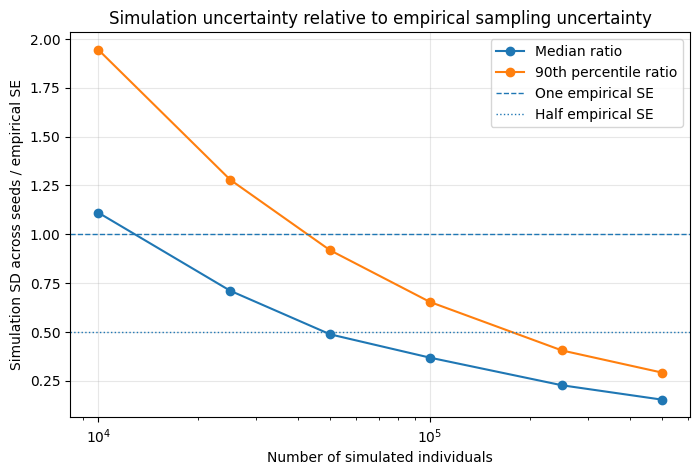

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    simulation_size_summary_overall["n_individuals"],
    simulation_size_summary_overall["median_sd_to_se"],
    marker="o",
    label="Median ratio",
)

ax.plot(
    simulation_size_summary_overall["n_individuals"],
    simulation_size_summary_overall["p90_sd_to_se"],
    marker="o",
    label="90th percentile ratio",
)

ax.axhline(1.0, linestyle="--", linewidth=1, label="One empirical SE")
ax.axhline(0.5, linestyle=":", linewidth=1, label="Half empirical SE")
ax.set_xscale("log")
ax.set_xlabel("Number of simulated individuals")
ax.set_ylabel("Simulation SD across seeds / empirical SE")
ax.set_title("Simulation uncertainty relative to empirical sampling uncertainty")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

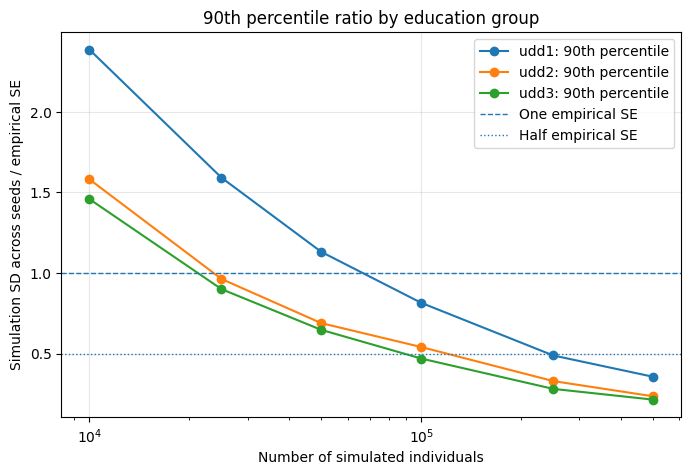

In [19]:

fig, ax = plt.subplots(figsize=(8, 5))

for education, df in simulation_size_summary_by_education.groupby("education"):
    ax.plot(
        df["n_individuals"],
        df["p90_sd_to_se"],
        marker="o",
        label=f"{education}: 90th percentile",
    )

ax.axhline(1.0, linestyle="--", linewidth=1, label="One empirical SE")
ax.axhline(0.5, linestyle=":", linewidth=1, label="Half empirical SE")
ax.set_xscale("log")
ax.set_xlabel("Number of simulated individuals")
ax.set_ylabel("Simulation SD across seeds / empirical SE")
ax.set_title("90th percentile ratio by education group")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### Table summary

In [20]:

simulation_time_summary = (
    simulated_moments_wide
    .drop_duplicates(["education", "n_individuals", "seed"])
    .groupby(["education", "n_individuals"], as_index=False)
    .agg(
        mean_sim_time_seconds=("sim_time_seconds", "mean"),
        sd_sim_time_seconds=("sim_time_seconds", "std"),
        min_sim_time_seconds=("sim_time_seconds", "min"),
        max_sim_time_seconds=("sim_time_seconds", "max"),
        n_seeds=("seed", "nunique"),
    )
    .sort_values(["education", "n_individuals"])
)

display(simulation_time_summary)

,education,n_individuals,mean_sim_time_seconds,sd_sim_time_seconds,min_sim_time_seconds,max_sim_time_seconds,n_seeds
0,udd1,10000,1.704289,0.493718,1.443485,3.078828,10
1,udd1,25000,2.618826,0.538356,2.392534,4.129596,10
2,udd1,50000,3.875589,0.485419,3.679633,5.255568,10
3,udd1,100000,7.105685,0.597823,6.871378,8.802257,10
4,udd1,250000,17.152196,0.566141,16.848799,18.728311,10
5,udd1,500000,34.837191,0.981887,33.848620,36.764490,10
6,udd2,10000,1.592367,0.392439,1.396981,2.678774,10
7,udd2,25000,2.508488,0.034832,2.480048,2.600358,10
8,udd2,50000,3.804992,0.042028,3.759887,3.911010,10
9,udd2,100000,7.141404,0.187542,7.021381,7.661159,10


## 17. Save output tables

The saved files can be used directly in the paper or inspected later.

In [21]:

OUTPUT_DIR = pp.STRUCTURAL_RESULTS_DIR / "simulation_size_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

empirical_moments_wide.to_csv(OUTPUT_DIR / "empirical_moments_wide_all.csv", index=False)
empirical_share_moments_wide.to_csv(OUTPUT_DIR / "empirical_share_moments_wide.csv", index=False)
empirical_sampling_error_long.to_csv(OUTPUT_DIR / "empirical_sampling_error_share_moments.csv", index=False)

simulated_moments_wide.to_csv(OUTPUT_DIR / "simulated_moments_wide_by_education_n_seed.csv", index=False)
simulated_share_moments_long.to_csv(OUTPUT_DIR / "simulated_share_moments_long_by_education_n_seed.csv", index=False)
simulation_uncertainty.to_csv(OUTPUT_DIR / "simulation_uncertainty_across_seeds.csv", index=False)
simulation_vs_sampling_error.to_csv(OUTPUT_DIR / "simulation_sd_vs_empirical_se.csv", index=False)
simulation_size_summary_by_education.to_csv(OUTPUT_DIR / "simulation_size_summary_by_education.csv", index=False)
simulation_size_summary_overall.to_csv(OUTPUT_DIR / "simulation_size_summary_overall.csv", index=False)
moment_level_summary.to_csv(OUTPUT_DIR / "simulation_size_moment_level_summary.csv", index=False)
worst_cells_by_education_n.to_csv(OUTPUT_DIR / "worst_age_moment_cells_by_education_n.csv", index=False)
simulation_time_summary.to_csv(OUTPUT_DIR / "simulation_time_summary.csv", index=False)
solver_summary.to_csv(OUTPUT_DIR / "solver_summary_by_education.csv", index=False)

print("Saved output tables to:", OUTPUT_DIR)

Saved output tables to: C:\Users\Nashw\Studiet\polit\2. Semester\DynamicProgramming\Thesis\dp_termpaper\results\structural estimation\simulation_size_analysis
